In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from google.colab import drive
drive.mount('/content/drive')

gold = pd.read_excel('/content/XAU-USD-2020-2025.xlsx')
dxy = pd.read_excel("/content/DXY-2020-2025.xlsx")
# Transform the file from csv to excel.
# This is an example, the name of the file can be replaced.

gold['Date'] = pd.to_datetime(gold['Date'], dayfirst=True)
dxy['Date'] = pd.to_datetime(dxy['Date'], dayfirst=True)

gold = gold[['Date', 'Close']].rename(columns={'Close': 'Gold'})
dxy = dxy[['Date', 'Close']].rename(columns={'Close': 'DXY'})

data = pd.merge(
    gold,
    dxy,
    on='Date',
    how='inner'
)
# Align the data

data = data.sort_values('Date').reset_index(drop=True)
data.to_excel("gold_dxy_aligned_2020-2025.xlsx", index=False)
# Create a new file in the order of date

print(data.head())
print(data.tail())
print(data.isna().sum())
# Test

MessageError: Error: credential propagation was unsuccessful

# 新段落

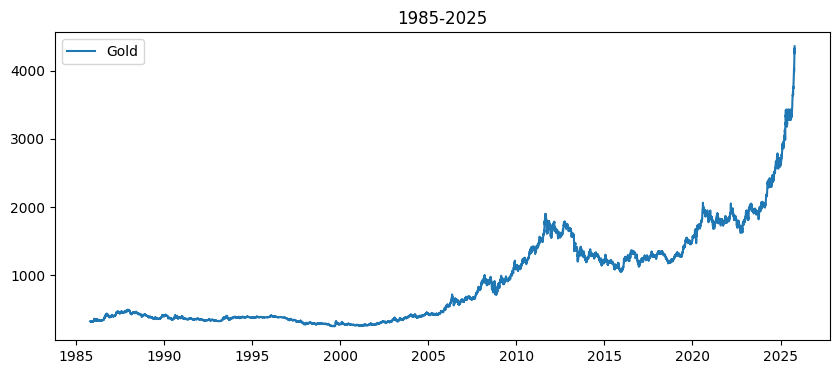

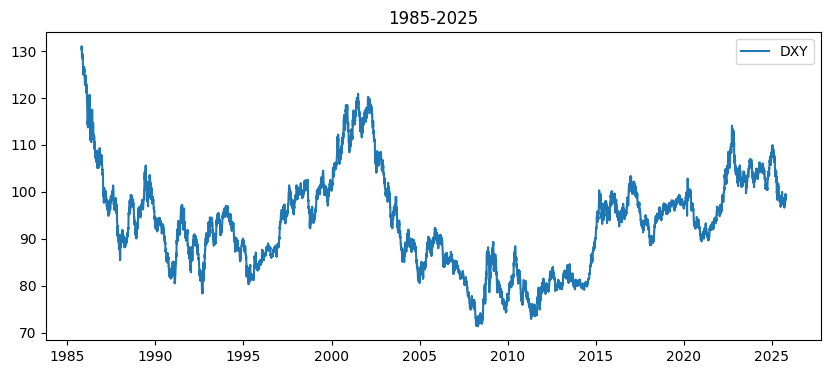

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(data['Date'], data['Gold'], label='Gold')
plt.title('1985-2025')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(data['Date'], data['DXY'], label='DXY')
plt.title('1985-2025')
plt.legend()
plt.show()

# Data visualization to see whether obvious errors are spotted

In [ ]:
print(f"The kurtosis of gold price is {data['Gold'].kurtosis()}")
print(f"The kurtosis of DXY is {data['DXY'].kurtosis()}")

The kurtosis of gold price is 1.5042394433793085
The kurtosis of DXY is 0.05861484249765425


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

data = pd.read_excel('/content/gold_dxy_aligned_1985-2025.xlsx')

# Apply ADF test on the data

def adf_test(series, name):
  for reg in ['c', 'ct', 'n']:
    result = adfuller(series.dropna(), regression=reg)
    print(f"{name}{reg}: ADF stat = {result[0]:.3f}, p-value = {result[1]:.3f}")

adf_test(data['Gold'], 'Gold (level)')
adf_test(data['DXY'], 'DXY (level)')
adf_test(data['Gold'].diff(), 'Gold (diff)')
adf_test(data['DXY'].diff(), 'DXY (diff)')

Gold (level)c: ADF stat = 5.069, p-value = 1.000
Gold (level)ct: ADF stat = 4.243, p-value = 1.000
Gold (level)n: ADF stat = 5.121, p-value = 1.000
DXY (level)c: ADF stat = -3.652, p-value = 0.005
DXY (level)ct: ADF stat = -3.583, p-value = 0.031
DXY (level)n: ADF stat = -1.060, p-value = 0.261
Gold (diff)c: ADF stat = -12.020, p-value = 0.000
Gold (diff)ct: ADF stat = -12.459, p-value = 0.000
Gold (diff)n: ADF stat = -11.744, p-value = 0.000
DXY (diff)c: ADF stat = -101.874, p-value = 0.000
DXY (diff)ct: ADF stat = -101.892, p-value = 0.000
DXY (diff)n: ADF stat = -101.875, p-value = 0.000


In [ ]:
data[['Gold', 'DXY']].describe()

,Gold,DXY
count,10339.000000,10339.000000
mean,907.537675,93.359295
std,685.128850,10.427559
min,252.550000,71.330000
25%,366.440000,85.480000
50%,484.950000,93.460000
75%,1320.760000,99.480000
max,4356.500000,131.030000


# 新段落

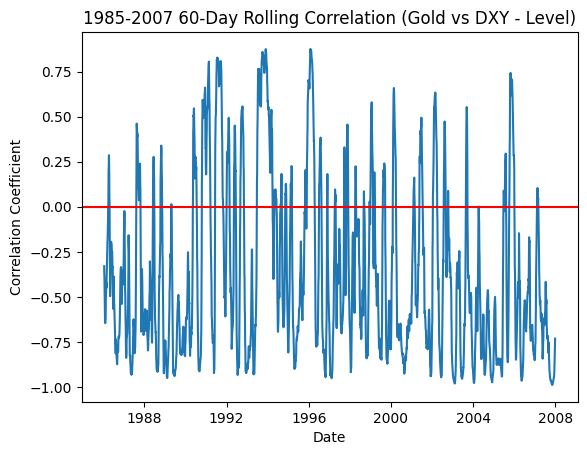

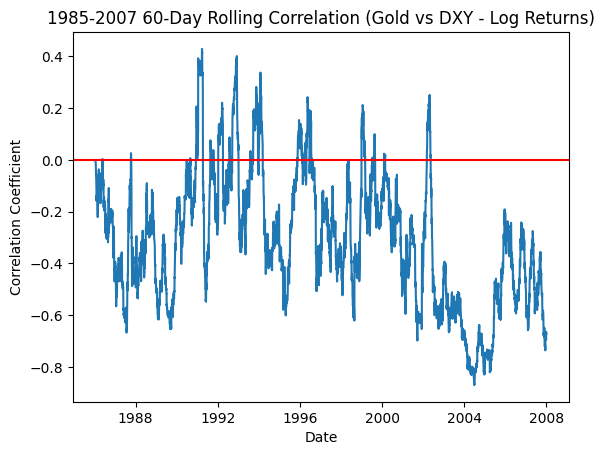

Average Level Rolling Correlation: -0.36157533843359224
Average Return Rolling Correlation: -0.30822198881960156


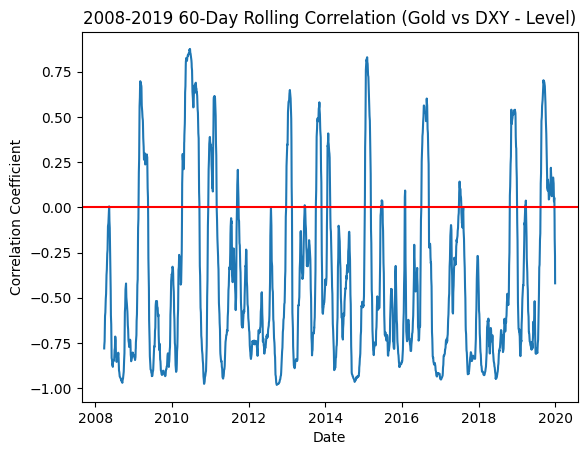

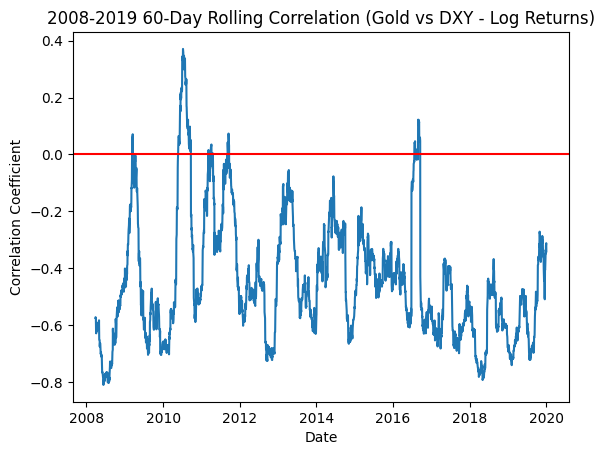

Average Level Rolling Correlation: -0.4099071429171072
Average Return Rolling Correlation: -0.4426160894402759


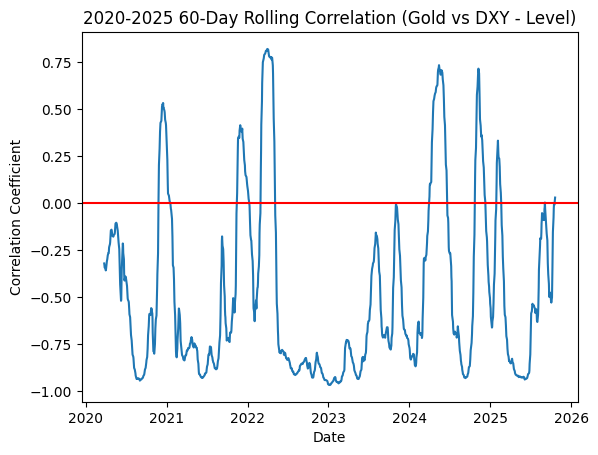

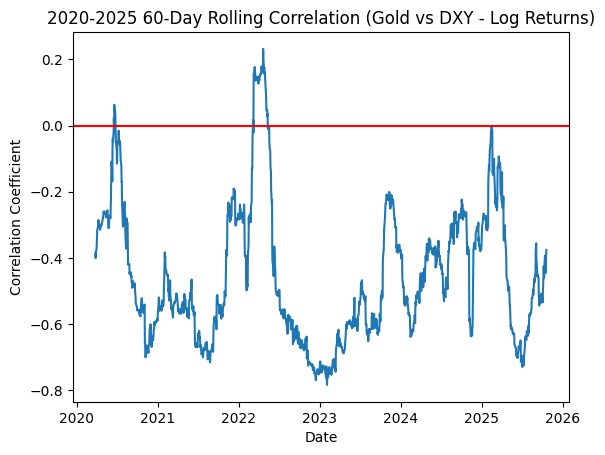

Average Level Rolling Correlation: -0.4768570047653111
Average Return Rolling Correlation: -0.4561980930763969


In [ ]:
# Rolling Window of length 60 days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Read the files
# =========================

path = [['/content/gold_dxy_aligned_1985-2007.xlsx', 60, 30, 120, '1985-2007'], ['/content/gold_dxy_aligned_2008-2019.xlsx', 60, 30, 120, '2008-2019'], ['/content/gold_dxy_aligned_2020-2025.xlsx', 60, 30, 120, '2020-2025']]

for i in path:
  df = pd.read_excel(i[0])

# Gurantee the file is called datetime
  df['Date'] = pd.to_datetime(df['Date'])

# Sort the data in dates
  df = df.sort_values('Date')

# =========================
# 2. Compute log return
# =========================

  df['Gold_log'] = np.log(df['Gold'])
  df['DXY_log'] = np.log(df['DXY'])

  df['Gold_ret'] = df['Gold_log'].diff()
  df['DXY_ret'] = df['DXY_log'].diff()

# Delete NA
  df = df.dropna()

# =========================
# 3. 设定 rolling window
# =========================

  window = i[1]   # 60天窗口

# =========================
# 4. Compute rolling correlation
# =========================

# Level rolling
  df['rolling_corr_level'] = (
    df['Gold']
    .rolling(window)
    .corr(df['DXY'])
)

# Return rolling
  df['rolling_corr_return'] = (
    df['Gold_ret']
    .rolling(window)
    .corr(df['DXY_ret'])
)

# =========================
# 5. Plot level data
# =========================

  plt.figure()
  plt.plot(df['Date'], df['rolling_corr_level'])
  plt.title(f'{i[4]} {i[1]}-Day Rolling Correlation (Gold vs DXY - Level)')
  plt.xlabel('Date')
  plt.ylabel('Correlation Coefficient')
  plt.axhline(0, color = 'red')
  plt.show()

# =========================
# 6. Plot return data
# =========================

  plt.figure()
  plt.plot(df['Date'], df['rolling_corr_return'])
  plt.title(f'{i[4]} {i[1]}-Day Rolling Correlation (Gold vs DXY - Log Returns)')
  plt.xlabel('Date')
  plt.ylabel('Correlation Coefficient')
  plt.axhline(0, color = 'red')
  plt.show()

# =========================
# 7. Output correlation coefficient
# =========================

  print("Average Level Rolling Correlation:",
      df['rolling_corr_level'].mean())

  print("Average Return Rolling Correlation:",
      df['rolling_corr_return'].mean())

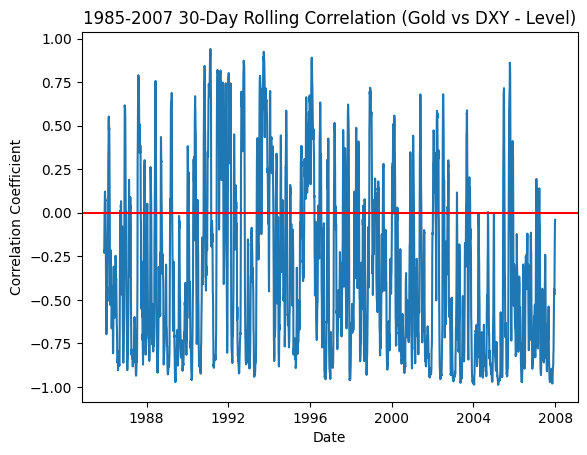

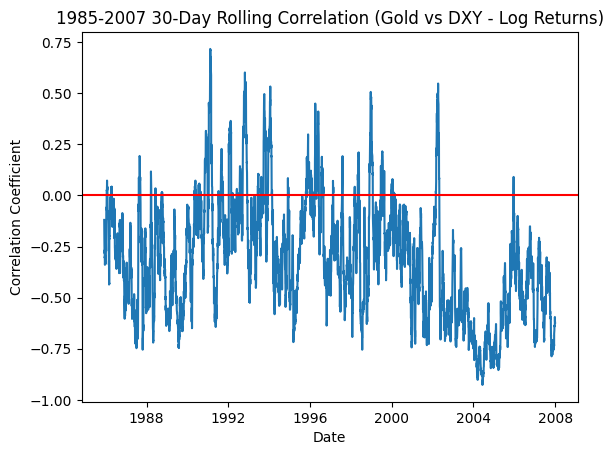

Average Level Rolling Correlation: -0.3399862419069743
Average Return Rolling Correlation: -0.3106214908126172


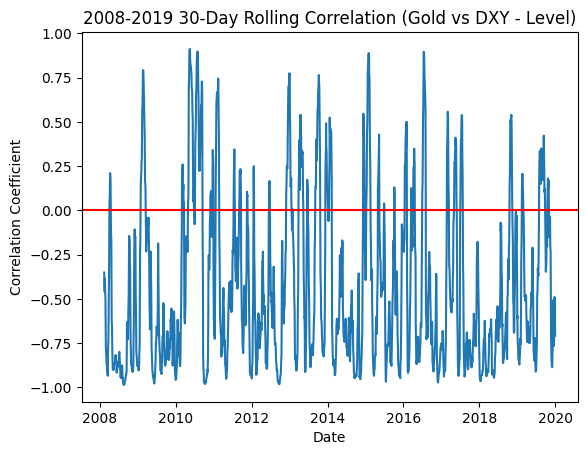

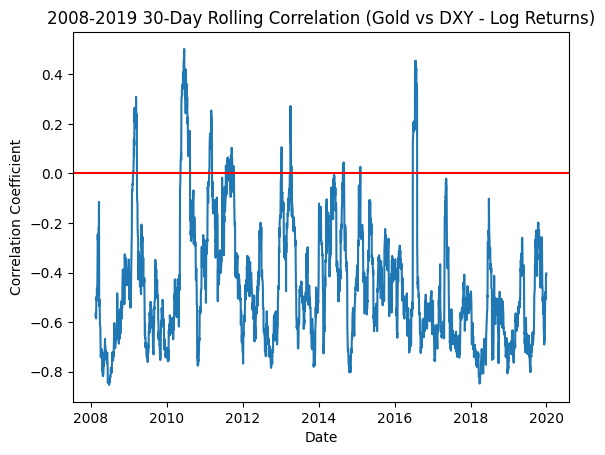

Average Level Rolling Correlation: -0.4295837654345575
Average Return Rolling Correlation: -0.4485432264043455


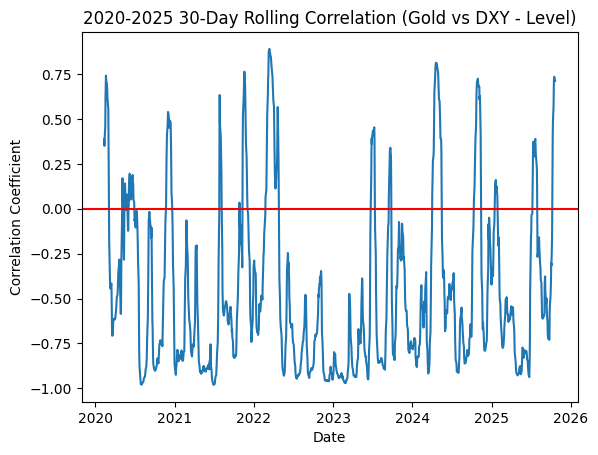

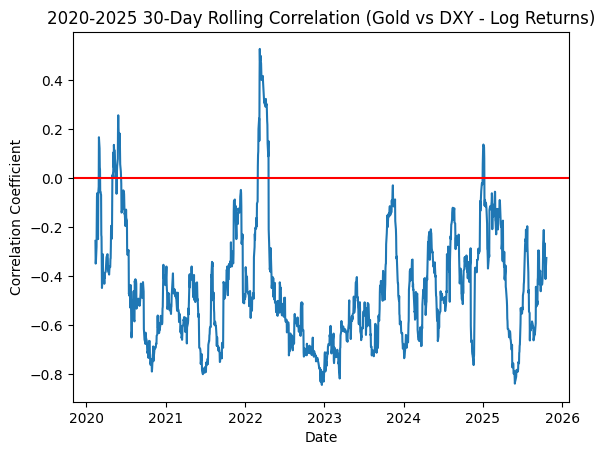

Average Level Rolling Correlation: -0.4629499177439529
Average Return Rolling Correlation: -0.45262559724690266


In [ ]:
# Rolling Window of length 30 days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. read the files
# =========================

path = [['/content/gold_dxy_aligned_1985-2007.xlsx', 60, 30, 120, '1985-2007'], ['/content/gold_dxy_aligned_2008-2019.xlsx', 60, 30, 120, '2008-2019'], ['/content/gold_dxy_aligned_2020-2025.xlsx', 60, 30, 120, '2020-2025']]

for i in path:
  df = pd.read_excel(i[0])

# 确保日期列为 datetime
  df['Date'] = pd.to_datetime(df['Date'])

# 排序
  df = df.sort_values('Date')

# =========================
# 2. compute log return
# =========================

  df['Gold_log'] = np.log(df['Gold'])
  df['DXY_log'] = np.log(df['DXY'])

  df['Gold_ret'] = df['Gold_log'].diff()
  df['DXY_ret'] = df['DXY_log'].diff()

# 删除 NA
  df = df.dropna()

# =========================
# 3. Set rolling window
# =========================

  window = i[2]   # 60天窗口

# =========================
# 4. Compute rolling correlation
# =========================

# Level rolling
  df['rolling_corr_level'] = (
    df['Gold']
    .rolling(window)
    .corr(df['DXY'])
)

# Return rolling
  df['rolling_corr_return'] = (
    df['Gold_ret']
    .rolling(window)
    .corr(df['DXY_ret'])
)

# =========================
# 5. Plot level data
# =========================

  plt.figure()
  plt.plot(df['Date'], df['rolling_corr_level'])
  plt.title(f'{i[4]} {i[2]}-Day Rolling Correlation (Gold vs DXY - Level)')
  plt.xlabel('Date')
  plt.ylabel('Correlation Coefficient')
  plt.axhline(0, color = 'red')
  plt.show()

# =========================
# 6. Plot return data
# =========================

  plt.figure()
  plt.plot(df['Date'], df['rolling_corr_return'])
  plt.title(f'{i[4]} {i[2]}-Day Rolling Correlation (Gold vs DXY - Log Returns)')
  plt.xlabel('Date')
  plt.ylabel('Correlation Coefficient')
  plt.axhline(0, color = 'red')
  plt.show()


# =========================
# 7. Output correlation coefficient
# =========================

  print("Average Level Rolling Correlation:",
      df['rolling_corr_level'].mean())

  print("Average Return Rolling Correlation:",
      df['rolling_corr_return'].mean())

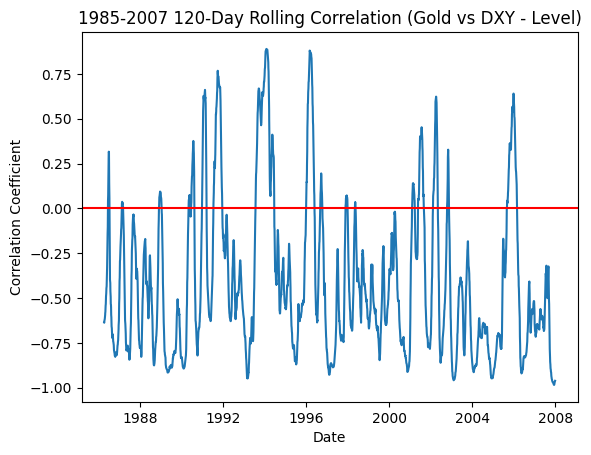

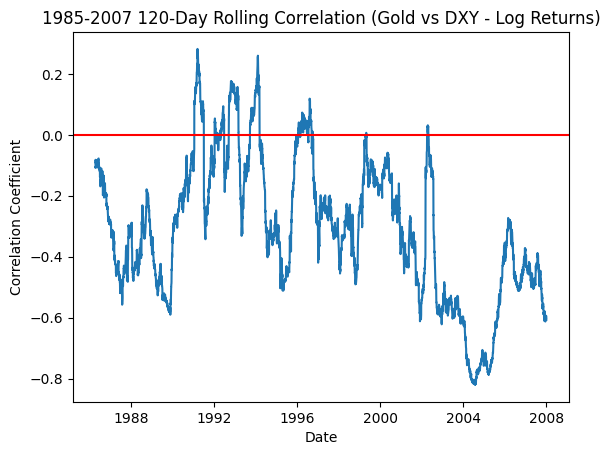

Average Level Rolling Correlation: -0.40155666362744497
Average Return Rolling Correlation: -0.3070011828023506


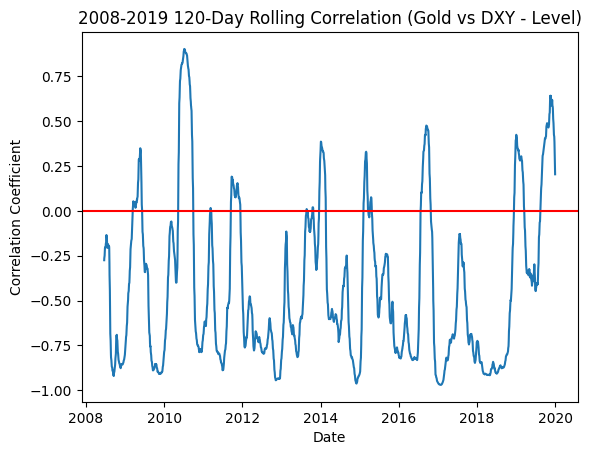

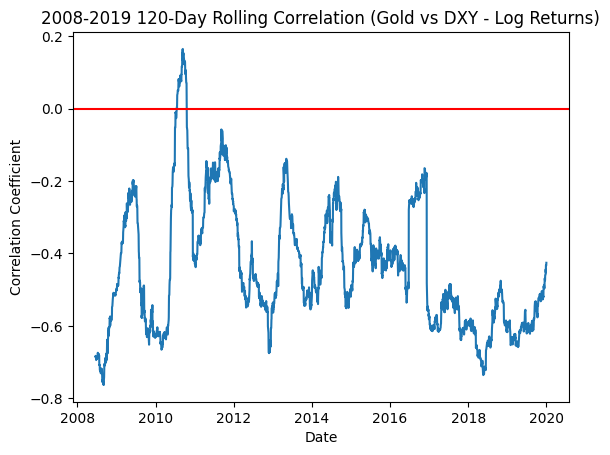

Average Level Rolling Correlation: -0.4255942864468623
Average Return Rolling Correlation: -0.4368273443656443


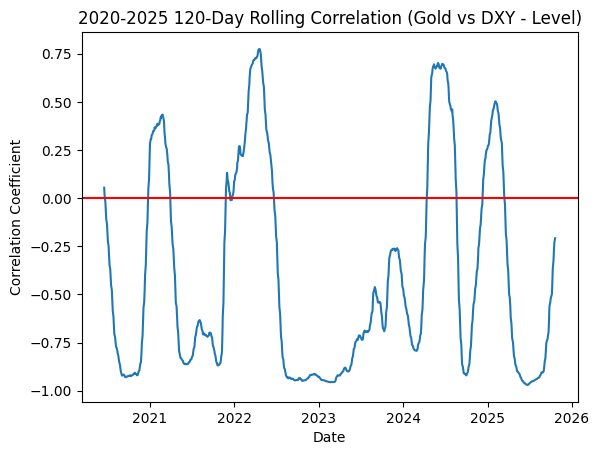

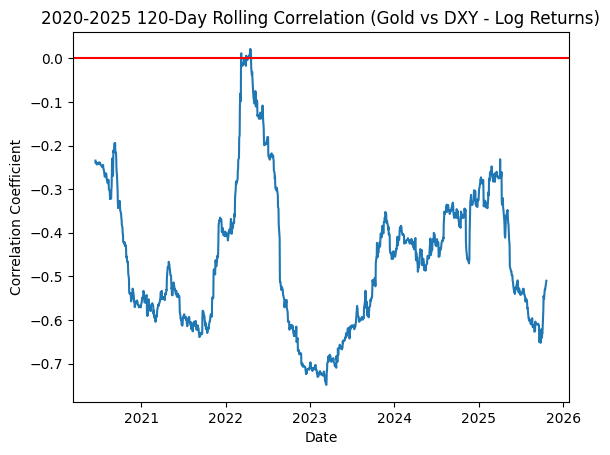

Average Level Rolling Correlation: -0.41125329846367725
Average Return Rolling Correlation: -0.4603448100081392


In [ ]:
# Rolling Window of length 120 days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Read the files
# =========================

path = [['/content/gold_dxy_aligned_1985-2007.xlsx', 60, 30, 120, '1985-2007'], ['/content/gold_dxy_aligned_2008-2019.xlsx', 60, 30, 120, '2008-2019'], ['/content/gold_dxy_aligned_2020-2025.xlsx', 60, 30, 120, '2020-2025']]

for i in path:
  df = pd.read_excel(i[0])
  df['Date'] = pd.to_datetime(df['Date'])
  df = df.sort_values('Date')

# =========================
# 2. Compute log return
# =========================

  df['Gold_log'] = np.log(df['Gold'])
  df['DXY_log'] = np.log(df['DXY'])

  df['Gold_ret'] = df['Gold_log'].diff()
  df['DXY_ret'] = df['DXY_log'].diff()

# Delete NA
  df = df.dropna()

# =========================
# 3. Set rolling window
# =========================

  window = i[3]   # 60天窗口

# =========================
# 4. Compute rolling correlation
# =========================

# Level rolling
  df['rolling_corr_level'] = (
    df['Gold']
    .rolling(window)
    .corr(df['DXY'])
)

# Return rolling
  df['rolling_corr_return'] = (
    df['Gold_ret']
    .rolling(window)
    .corr(df['DXY_ret'])
)

# =========================
# 5. Plot level data
# =========================

  plt.figure()
  plt.plot(df['Date'], df['rolling_corr_level'])
  plt.title(f'{i[4]} {i[3]}-Day Rolling Correlation (Gold vs DXY - Level)')
  plt.xlabel('Date')
  plt.ylabel('Correlation Coefficient')
  plt.axhline(0, color = 'red')
  plt.show()

# =========================
# 6. Plot return data
# =========================

  plt.figure()
  plt.plot(df['Date'], df['rolling_corr_return'])
  plt.title(f'{i[4]} {i[3]}-Day Rolling Correlation (Gold vs DXY - Log Returns)')
  plt.xlabel('Date')
  plt.ylabel('Correlation Coefficient')
  plt.axhline(0, color = 'red')
  plt.show()

# =========================
# 7. Output correlation cofficient
# =========================

  print("Average Level Rolling Correlation:",
      df['rolling_corr_level'].mean())

  print("Average Return Rolling Correlation:",
      df['rolling_corr_return'].mean())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -20.01     -20.01*   2.036e-09     -20.01*
1      -20.01*      -20.01  2.034e-09*      -20.01
2       -20.01      -20.00   2.036e-09      -20.01
3       -20.01      -20.00   2.037e-09      -20.01
4       -20.01      -19.99   2.038e-09      -20.00
5       -20.01      -19.98   2.041e-09      -20.00
6       -20.01      -19.98   2.041e-09      -20.00
7       -20.01      -19.97   2.042e-09      -20.00
8       -20.01      -19.97   2.045e-09      -19.99
9       -20.01      -19.96   2.047e-09      -19.99
10      -20.01      -19.96   2.045e-09      -19.99
--------------------------------------------------
Selected lag (Full sample): 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Feb, 2026
Time:                     02:50:12
------------------------------

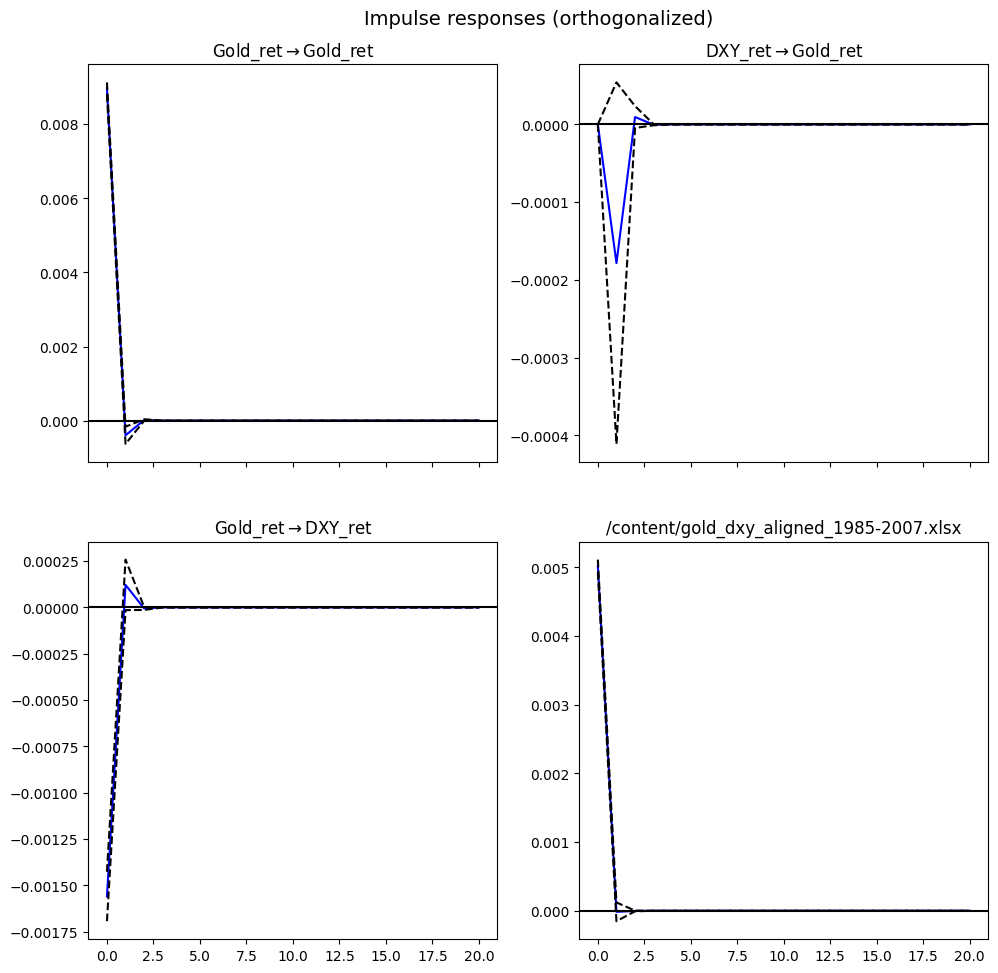

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -19.81     -19.80*   2.501e-09     -19.81*
1       -19.81      -19.79   2.502e-09      -19.80
2      -19.81*      -19.79  2.499e-09*      -19.80
3       -19.81      -19.78   2.500e-09      -19.80
4       -19.80      -19.77   2.506e-09      -19.79
5       -19.80      -19.76   2.509e-09      -19.79
6       -19.80      -19.75   2.509e-09      -19.79
7       -19.80      -19.74   2.515e-09      -19.78
8       -19.80      -19.73   2.515e-09      -19.78
9       -19.80      -19.73   2.511e-09      -19.78
10      -19.80      -19.72   2.513e-09      -19.77
--------------------------------------------------
Selected lag (Full sample): 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Feb, 2026
Time:                     02:50:14
------------------------------

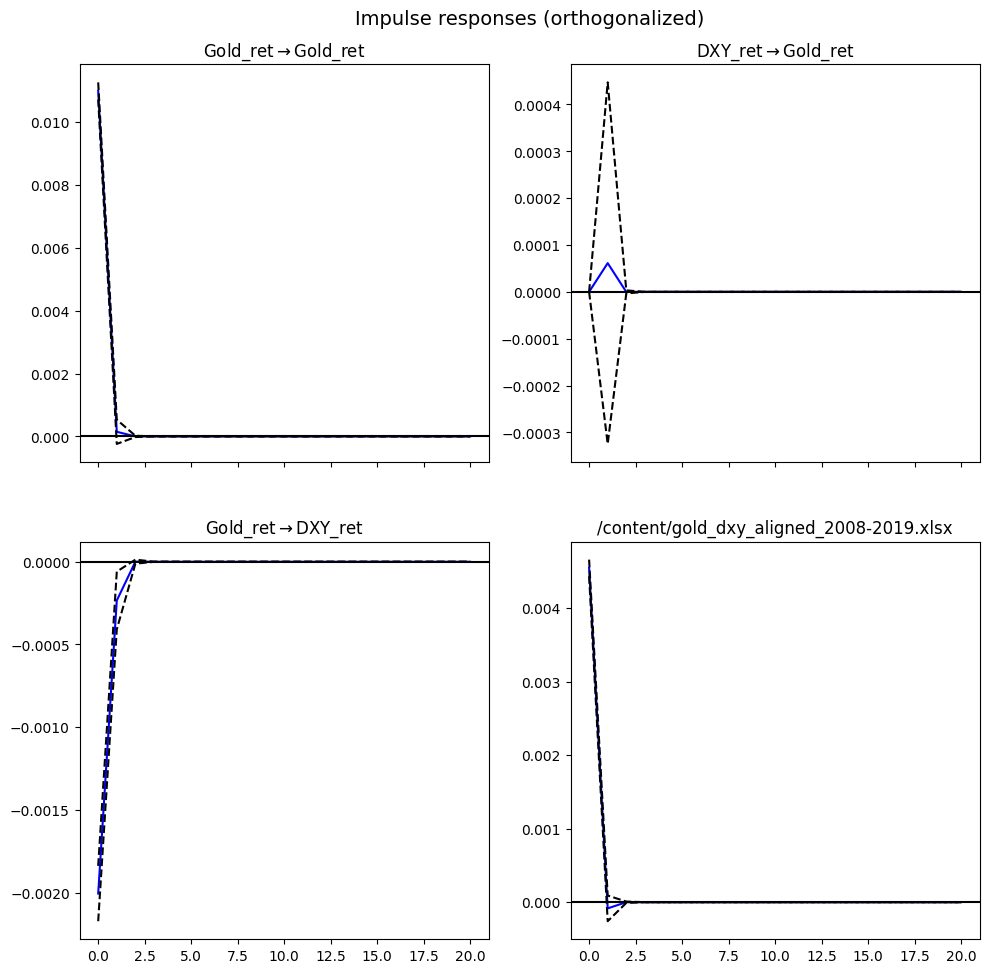

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -20.29     -20.28*   1.544e-09      -20.29
1      -20.30*      -20.27  1.533e-09*     -20.29*
2       -20.29      -20.26   1.539e-09      -20.28
3       -20.29      -20.24   1.535e-09      -20.28
4       -20.29      -20.23   1.541e-09      -20.27
5       -20.29      -20.21   1.548e-09      -20.26
6       -20.29      -20.19   1.546e-09      -20.25
7       -20.28      -20.18   1.553e-09      -20.24
8       -20.28      -20.16   1.556e-09      -20.24
9       -20.28      -20.14   1.562e-09      -20.23
10      -20.27      -20.12   1.568e-09      -20.22
--------------------------------------------------
Selected lag (Full sample): 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Feb, 2026
Time:                     02:50:15
------------------------------

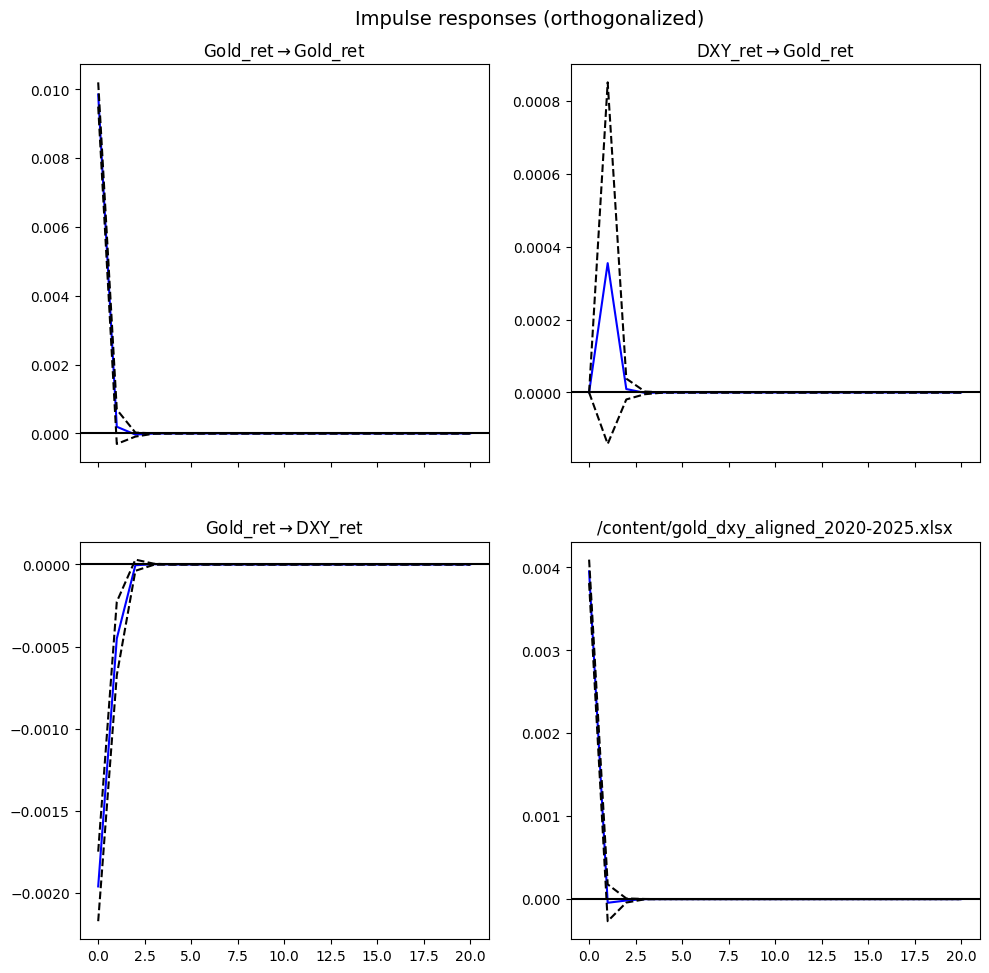

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -19.96*     -19.96*  2.142e-09*     -19.96*
1       -19.96      -19.96   2.143e-09      -19.96
2       -19.96      -19.95   2.143e-09      -19.96
3       -19.96      -19.95   2.143e-09      -19.96
4       -19.96      -19.95   2.144e-09      -19.96
5       -19.96      -19.94   2.145e-09      -19.95
6       -19.96      -19.94   2.145e-09      -19.95
7       -19.96      -19.94   2.146e-09      -19.95
8       -19.96      -19.94   2.146e-09      -19.95
9       -19.96      -19.93   2.147e-09      -19.95
10      -19.96      -19.93   2.148e-09      -19.95
--------------------------------------------------
Selected lag (Full sample): 0
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Feb, 2026
Time:                     02:50:18
------------------------------

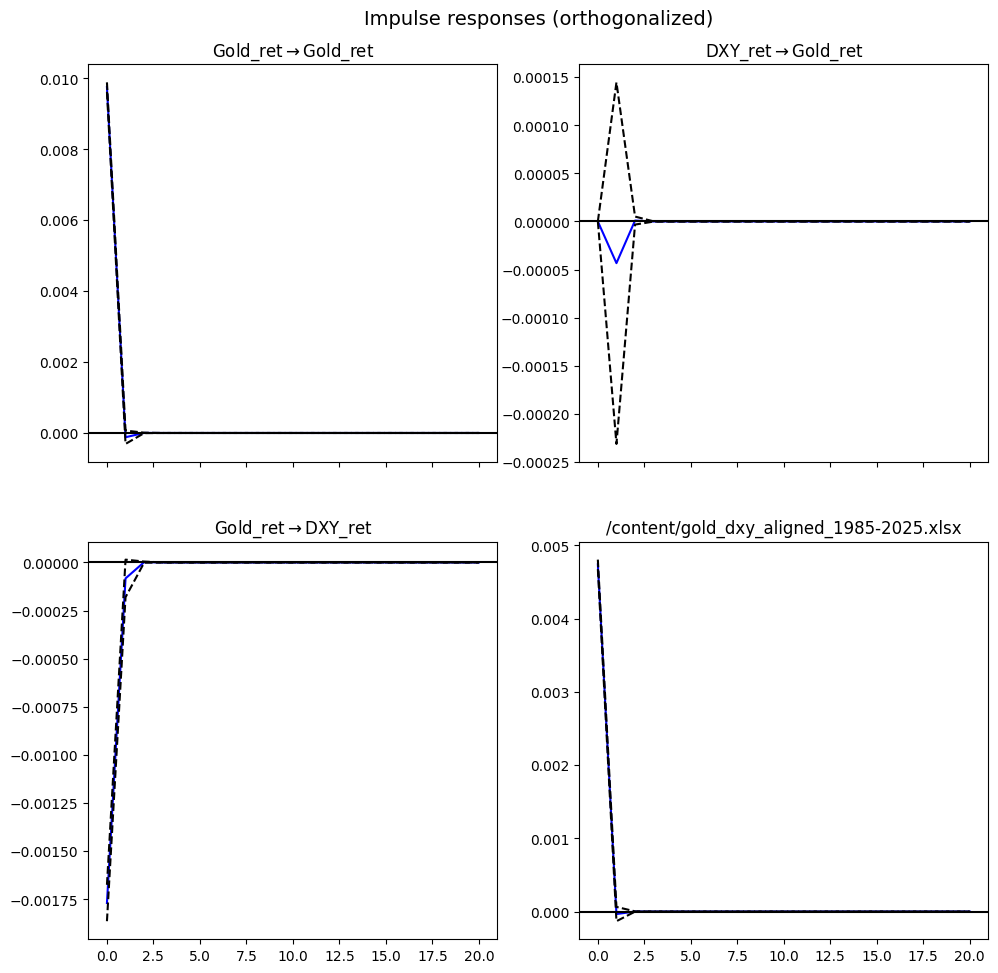

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

for i in ['/content/gold_dxy_aligned_1985-2007.xlsx', '/content/gold_dxy_aligned_2008-2019.xlsx', '/content/gold_dxy_aligned_2020-2025.xlsx', '/content/gold_dxy_aligned_1985-2025.xlsx']:



# Read the files
  df = pd.read_excel(i)


# Process the date
  df['Date'] = pd.to_datetime(df['Date'])
  df = df.sort_values('Date')
  df = df.set_index('Date')

# Compute log return
  df['Gold_ret'] = np.log(df['Gold']).diff()
  df['DXY_ret'] = np.log(df['DXY']).diff()

# Delete NA
  df = df.dropna()

# Retain return only
  data = df[['Gold_ret', 'DXY_ret']]

# Establish VAR model
  model_full = VAR(data)

# Automatically choose lag, at most order 10
  lag_order_full = model_full.select_order(maxlags=10)
  print(lag_order_full.summary())

# Use AIC to choose lag
  lag_full = lag_order_full.aic
  print("Selected lag (Full sample):", lag_full)

# Best-fit model
  results_full = model_full.fit(1)

  print(results_full.summary())

  irf_full = results_full.irf(20)  # 20期冲击响应
  fig = irf_full.plot(orth=True)


  plt.title(f'{i}')
  plt.savefig("irf_full.png", dpi=300)
  plt.show()
